In [219]:
import yfinance as yp

In [220]:
aapl = yp.Ticker("aapl")

In [221]:
aapl

yfinance.Ticker object <AAPL>

In [222]:
appl_history = aapl.history(start="2026-03-17", end="2026-03-23", interval="1m")
appl_history

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-03-17 09:30:00-04:00,253.078506,253.300003,252.179993,252.585007,784532,0.0,0.0
2026-03-17 09:31:00-04:00,252.550003,252.839996,252.440002,252.839996,57028,0.0,0.0
2026-03-17 09:32:00-04:00,252.893204,253.205002,252.699997,253.080002,90879,0.0,0.0
2026-03-17 09:33:00-04:00,253.050003,253.230499,252.740005,253.209900,66352,0.0,0.0
2026-03-17 09:34:00-04:00,253.199997,253.589706,253.160095,253.559998,60372,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-20 15:55:00-04:00,247.309998,247.770004,247.235001,247.770004,353021,0.0,0.0
2026-03-20 15:56:00-04:00,247.800003,247.829895,247.649994,247.779999,240495,0.0,0.0
2026-03-20 15:57:00-04:00,247.800003,248.000000,247.779999,247.880005,286401,0.0,0.0


In [223]:
dataset = yp.download("aapl",period="1y")
dataset

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-24,219.772141,220.518886,217.631476,220.040973,44299500
2025-03-25,222.779022,223.127509,219.124950,219.811958,34493600
2025-03-26,220.568680,224.043541,219.513282,222.540083,34466100
2025-03-27,222.878616,224.013669,219.602885,220.429285,37094800
2025-03-28,216.954422,222.838779,216.735375,220.708066,39818600
...,...,...,...,...,...
2026-03-17,254.229996,255.130005,252.179993,252.960007,32361600
2026-03-18,249.940002,254.940002,249.000000,252.630005,35757900


In [224]:
dataset.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

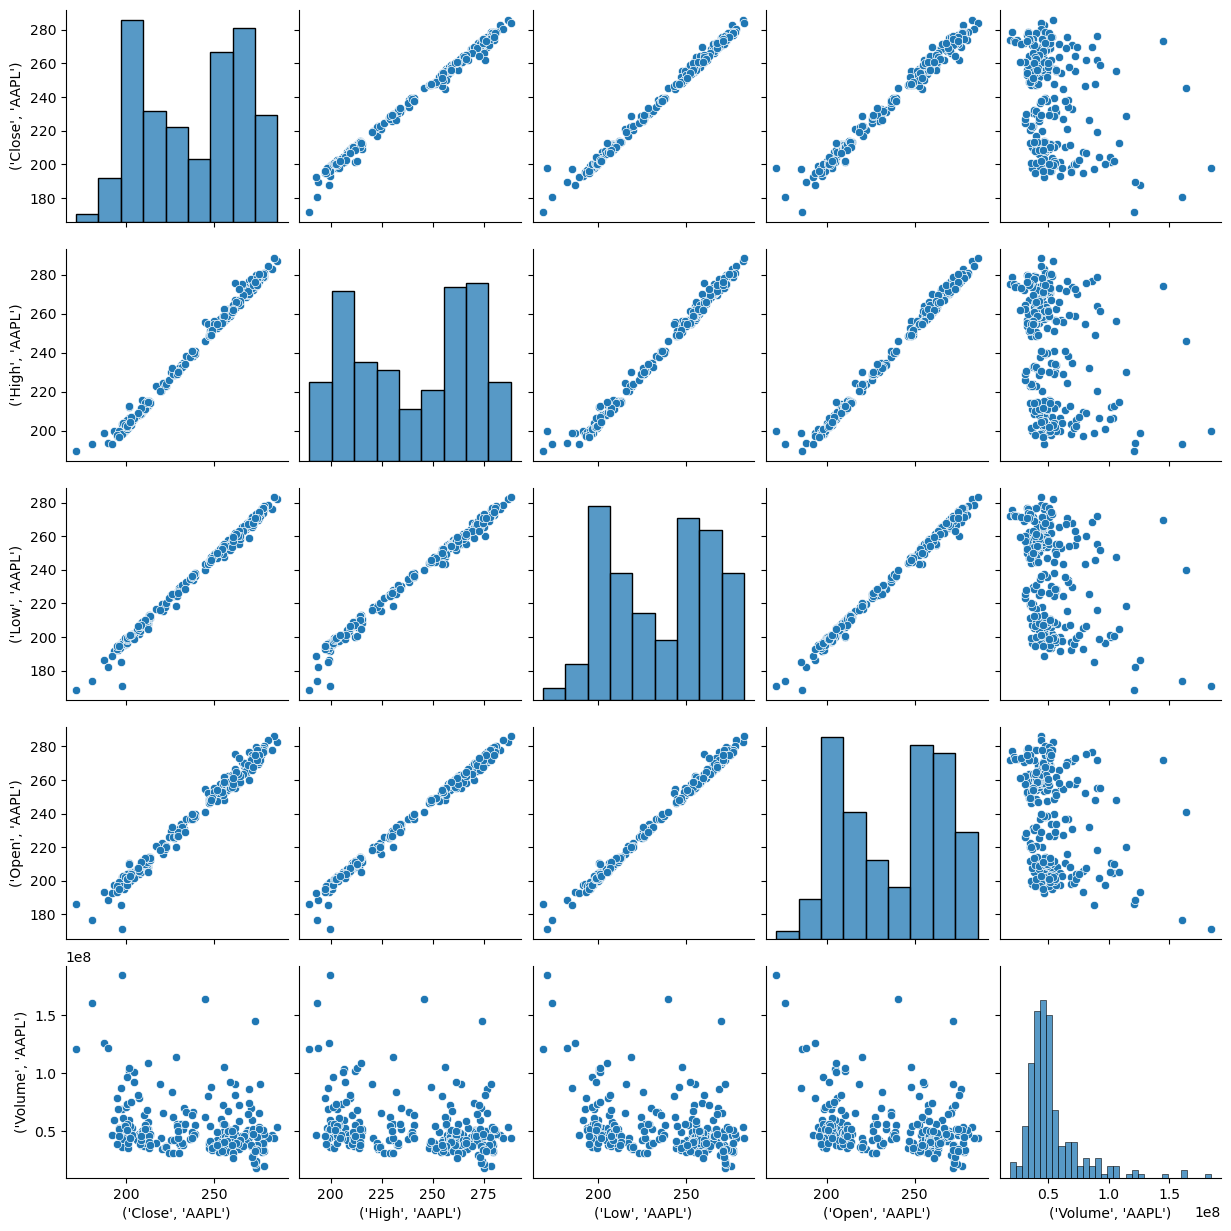

In [226]:
sns.pairplot(data=dataset)

In [227]:
import pandas as pd

In [228]:
dataset["Daily return"] = (dataset["Close"] - dataset["Open"]) / dataset["Open"]

In [229]:
dataset["Daily range"]  = (dataset["High"] - dataset["Low"])

In [230]:
dataset["Volume change"] = dataset["Volume"] / dataset["Volume"].shift(1)

In [231]:
dataset

Price,Close,High,Low,Open,Volume,Daily return,Daily range,Volume change
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2025-03-24,219.772141,220.518886,217.631476,220.040973,44299500,-0.001222,2.887409,NaN
2025-03-25,222.779022,223.127509,219.124950,219.811958,34493600,0.013498,4.002559,0.778645
2025-03-26,220.568680,224.043541,219.513282,222.540083,34466100,-0.008859,4.530259,0.999203
2025-03-27,222.878616,224.013669,219.602885,220.429285,37094800,0.011112,4.410784,1.076269
2025-03-28,216.954422,222.838779,216.735375,220.708066,39818600,-0.017007,6.103404,1.073428
...,...,...,...,...,...,...,...,...
2026-03-17,254.229996,255.130005,252.179993,252.960007,32361600,0.005021,2.950012,1.008960
2026-03-18,249.940002,254.940002,249.000000,252.630005,35757900,-0.010648,5.940002,1.104948


In [232]:
dataset.columns = dataset.columns.droplevel(1)

In [233]:
info = pd.DataFrame(data=dataset,columns=["Daily return","Daily range","Volume change"])
info = info.dropna()

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns

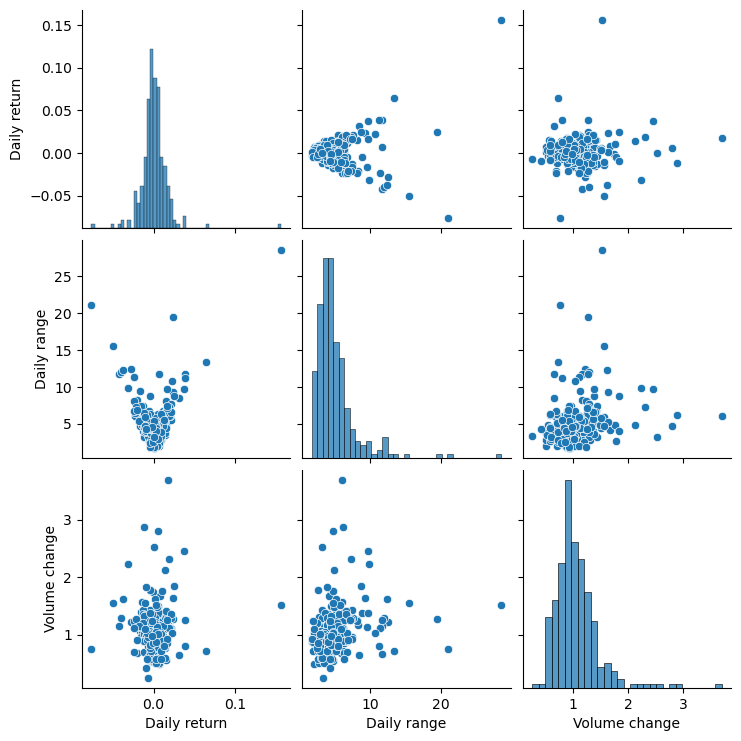

In [235]:
sns.pairplot(info)

In [236]:
from sklearn.cluster import AgglomerativeClustering

In [237]:
import scipy.cluster.hierarchy as sc

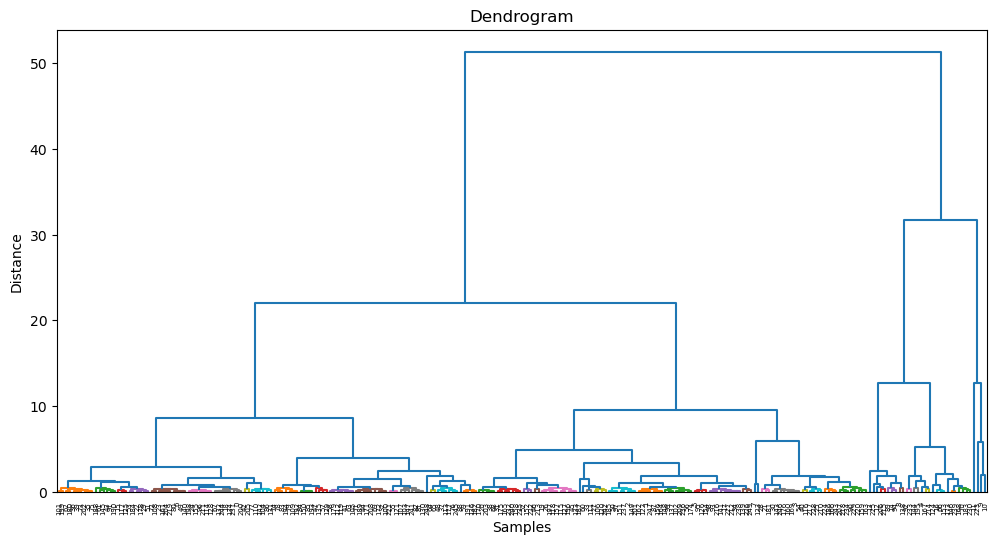

In [ ]:
plt.figure(figsize=(12, 6))
sc.dendrogram(
    sc.linkage(info.to_numpy(), method="ward", metric='euclidean'),
    color_threshold=0.5 
)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [213]:
from sklearn.cluster import AgglomerativeClustering

In [242]:
ac = AgglomerativeClustering(n_clusters=3,linkage="ward")
info["Prediction"] = ac.fit_predict(info)

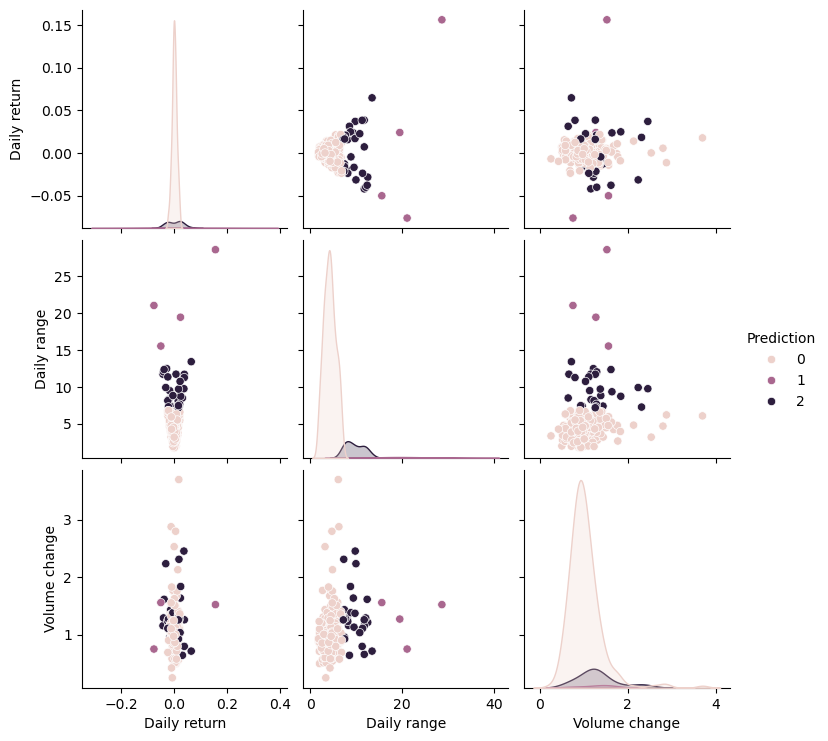

In [243]:
sns.pairplot(data=info,hue="Prediction")

In [244]:
info.groupby("Prediction")[["Daily return", "Daily range", "Volume change"]].mean()

,Daily return,Daily range,Volume change
Prediction,,,
0,0.000270,4.205165,1.024928
1,0.013426,21.154731,1.278641
2,0.002557,9.621589,1.311199
